In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings 
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('D:\ML\machne\House1.csv')

In [3]:
df.shape

(545, 13)

In [4]:
df.drop_duplicates(inplace=True)
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
yncos=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for n in yncos:
    print(df[n].value_counts())

mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
no     417
yes    128
Name: count, dtype: int64


In [8]:
for n in yncos:
    df[n]=df[n].map({'yes':1,'no':0})

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['furnishingstatus']=le.fit_transform(df['furnishingstatus'])
cos=['bedrooms', 'bathrooms', 'stories', 'mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','parking', 'prefarea', 'furnishingstatus']

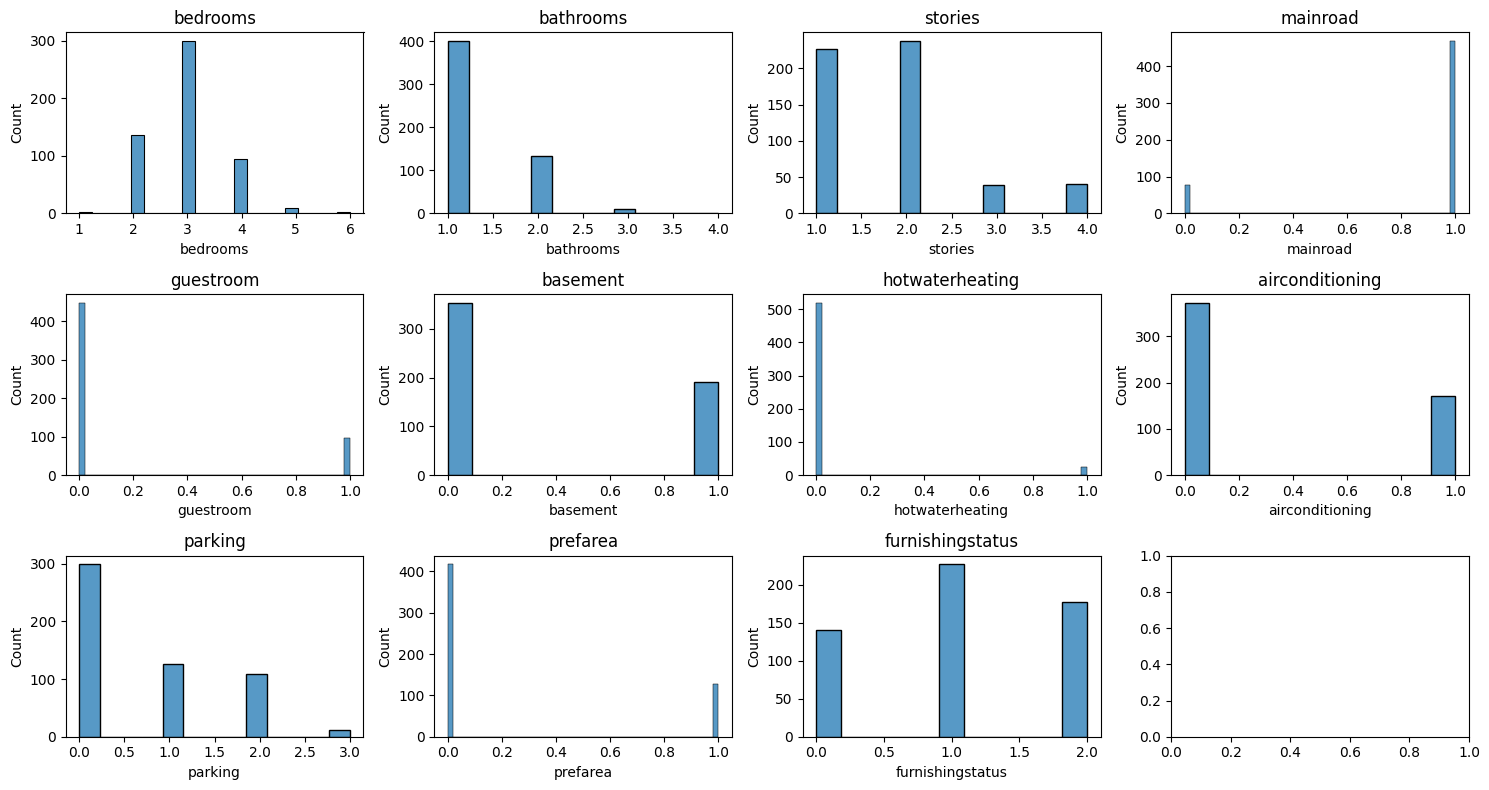

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for i, col in enumerate(cos):
    sns.histplot(x=col, data=df, ax=axes[i//4, i%4])
    axes[i//4, i%4].set_title(col)

plt.tight_layout()
plt.show()


In [11]:
df.corr(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.104672
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,-0.156726
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,-0.118328
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,-0.112831
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,-0.031628
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.150477


In [12]:
df=df.drop(['hotwaterheating','mainroad'],axis=1)

In [13]:
df=df.drop(['guestroom','prefarea'],axis=1)

In [14]:
from sklearn.model_selection import train_test_split
x=df.drop('price',axis=1)
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


In [15]:
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error
r2=r2_score(y_test,y_pred)
r2

0.6084802212010401

In [16]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(model,x,y,cv=5,scoring='r2')
print(score)

[ -2.17116123  -4.53210126 -18.84877847 -24.50721024  -6.94778193]


In [17]:
print(score.mean())

-11.401406625470594


In [ ]:
import xgboost as xgb
model1=xgb.XGBRegressor(objective='reg:squarederror',max_depth=5,learning_rate=0.1, n_estimators=1000,n_jobs=-1)
model1.fit(x_train,y_train)
y_pred=model1.predict(x_test)
print(r2_score(y_test,y_pred))

XGBoostError: [22:40:14] C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:119: Check failed: is_valid: base_score must be in (0,1) for the logistic loss.

In [19]:
from sklearn.ensemble import RandomForestRegressor
model2=RandomForestRegressor(n_estimators=200,random_state=42)
model2.fit(x_train,y_train)
y_pred=model2.predict(x_test)
print(r2_score(y_test,y_pred))

0.5817682757999643


In [20]:
from sklearn.model_selection import KFold
kfod=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model2,x,y,cv=kfod,scoring='r2')
print(scores)



[0.58438674 0.64911374 0.44775077 0.65468009 0.62514744]


In [21]:
print(scores.mean())

0.5922157561116626


In [26]:
from sklearn.preprocessing import PolynomialFeatures
pof=PolynomialFeatures(degree=2)
xpo=pof.fit_transform(x_train)
xpo1=pof.fit_transform(x_test)
mode=LinearRegression()
mode.fit(xpo,y_train)
y_pred=mode.predict(xpo1)


In [29]:
ypo=pof.fit_transform(y_train)
ypo1=pof.fit_transform(y_test)
print(mode.score(ypo,ypo1))

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.